<a href="https://colab.research.google.com/github/nadiastoyanova/project-nlp-challenge/blob/main/week4solutionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Links to the files

In [ ]:
data_url = "https://raw.githubusercontent.com/ironhack-labs/project-nlp-challenge/refs/heads/main/dataset/data.csv"

real_data_url = "https://raw.githubusercontent.com/ironhack-labs/project-nlp-challenge/refs/heads/main/dataset/validation_data.csv"

In [ ]:
# Install the required packages
!pip install numpy pandas scikit-learn matplotlib seaborn tabulate

# Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd

data = pd.read_csv(data_url)

# look at the data format
display(data.head(10))

,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
5,1,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,"December 29, 2017"
6,1,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,"December 29, 2017"
7,1,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
8,1,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
9,1,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,"December 28, 2017"


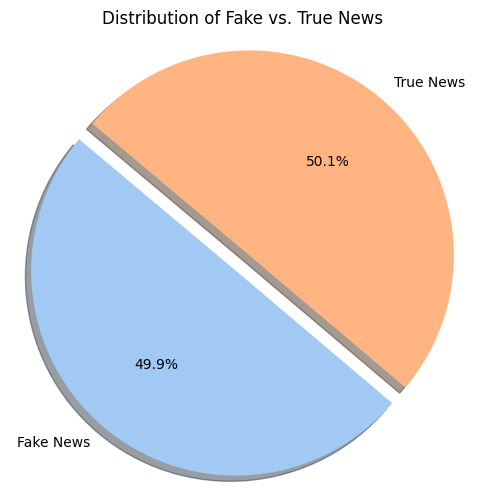

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fake_news_count = data['label'].value_counts()[0]
true_news_count = data['label'].value_counts()[1]

# Data for the pie chart
labels = ['Fake News', 'True News']
sizes = [fake_news_count, true_news_count]
# Use seaborn pastel palette
colors = sns.color_palette('pastel')[0:2]
explode = (0.1, 0)

plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.axis('equal')
plt.title('Distribution of Fake vs. True News')
plt.show()

As the count of fake news and true news has not so much variation, we are not going with sampling of data.

## Title and Text Length Comparision

As fake news can be using very bloated text or very short attention seeking text, a general idea of the length of text could give us a lot of idea on classification.

In [ ]:
data['title_length'] = data['title'].apply(len)
data['text_length'] = data['text'].apply(len)

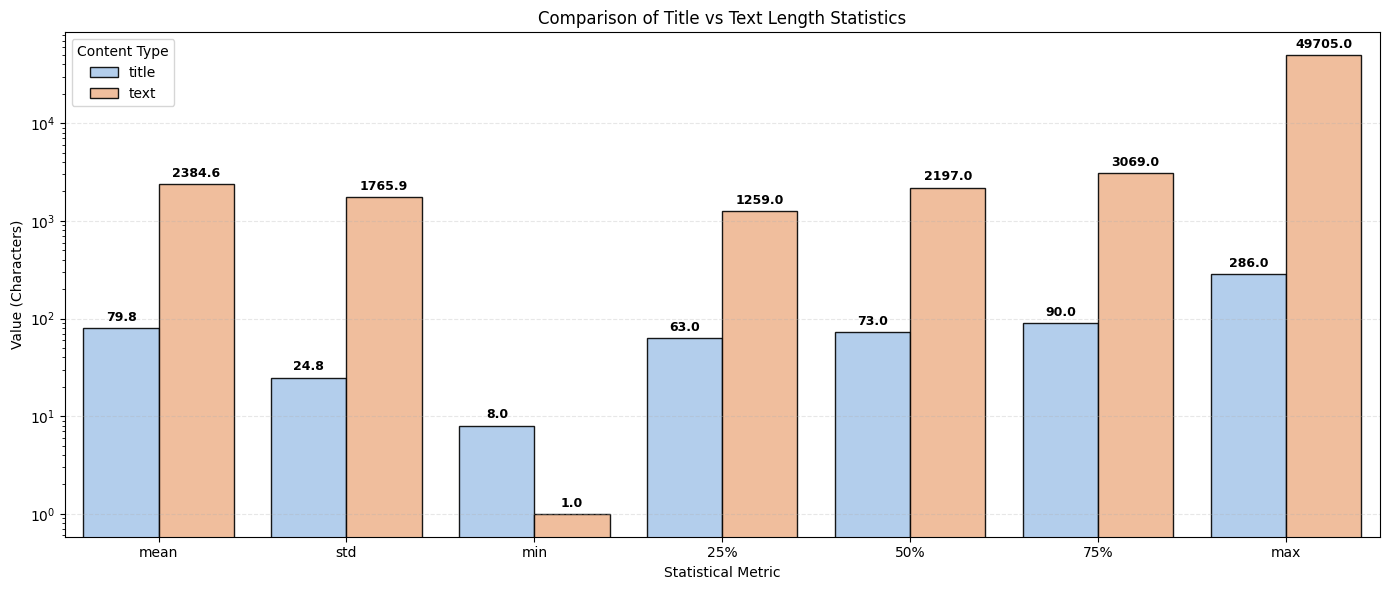

In [ ]:
# Use basic statistics and visualize with Seaborn using pastel palette and bar labels
from tabulate import tabulate
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = {}
results['title'] = data['title_length'].describe()
results['text'] = data['text_length'].describe()

df = pd.DataFrame(results)

# Prepare data for Seaborn plotting
df_plot = df.drop('count').reset_index().melt(id_vars='index', var_name='Type', value_name='Length')

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_plot, x='index', y='Length', hue='Type', palette='pastel', edgecolor='black', alpha=0.9)

# Adding values on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontweight='bold', fontsize=9)

plt.title('Comparison of Title vs Text Length Statistics')
plt.xlabel('Statistical Metric')
plt.ylabel('Value (Characters)')
plt.yscale('log') # Using log scale because text length is significantly larger than title
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

## Text length comparision


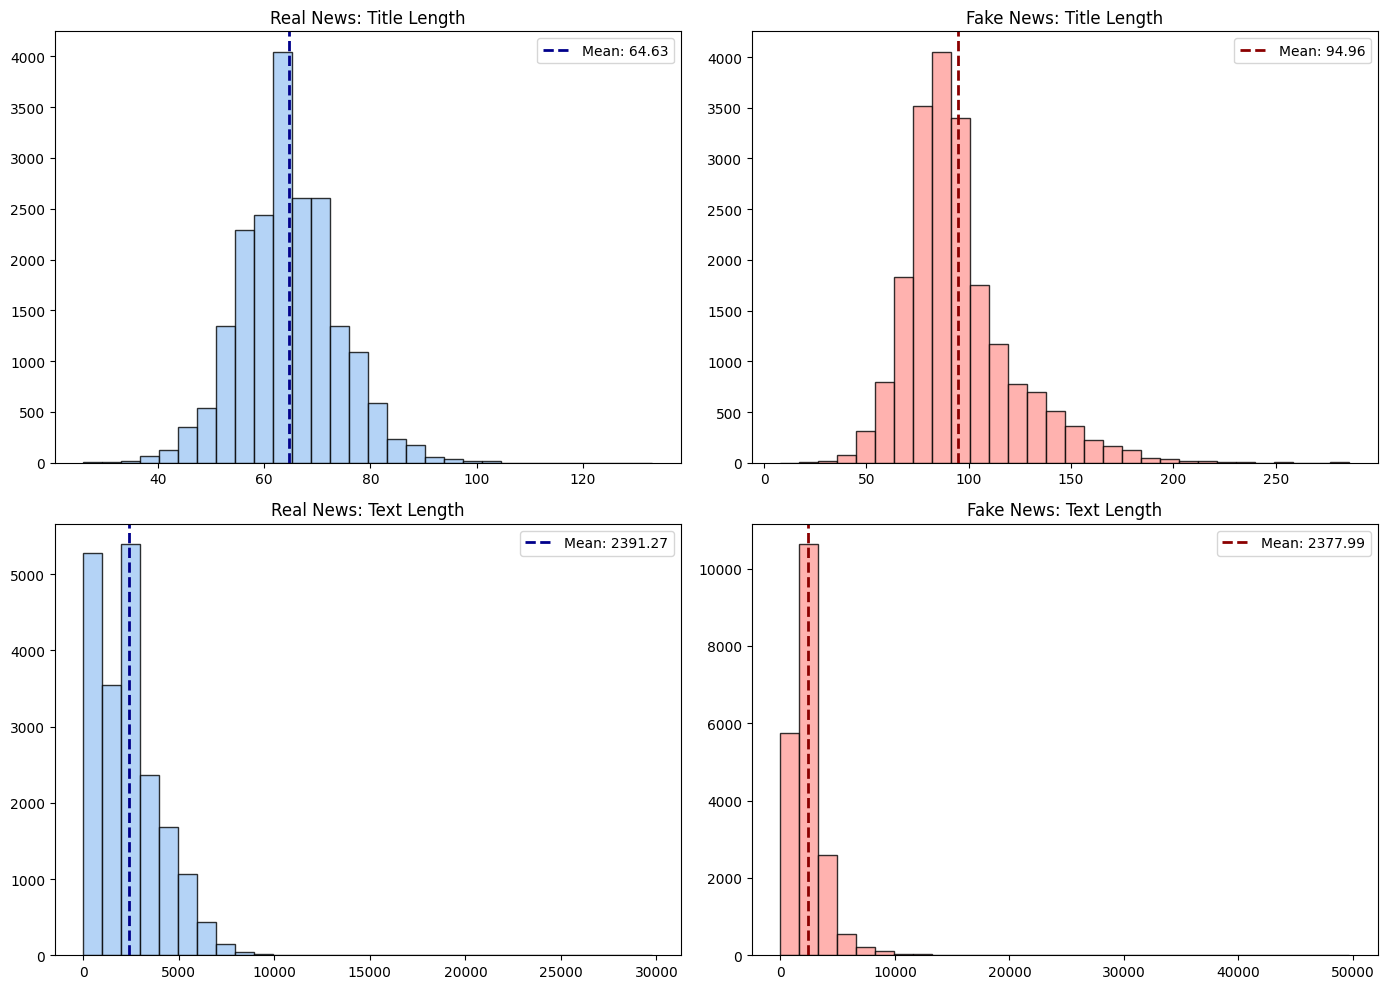

In [ ]:
# Ensure columns exist and create histograms comparing Real vs Fake news lengths
import matplotlib.pyplot as plt
import seaborn as sns

# Re-calculate lengths to be absolutely sure they exist in 'data'
data['title_length'] = data['title'].apply(len)
data['text_length'] = data['text'].apply(len)

# Get pastel colors
pastel_colors = sns.color_palette('pastel')
blue_pastel = pastel_colors[0]
red_pastel = pastel_colors[3]

# Refresh subsets
data_real = data[data['label'] == 1]
data_fake = data[data['label'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Real News - Title Length
title_mean_real = data_real['title_length'].mean()
axes[0, 0].hist(data_real['title_length'], bins=30, color=blue_pastel, alpha=0.8, edgecolor='black')
axes[0, 0].axvline(title_mean_real, color='darkblue', linestyle='dashed', linewidth=2, label=f'Mean: {title_mean_real:.2f}')
axes[0, 0].set_title('Real News: Title Length')
axes[0, 0].legend()

# Fake News - Title Length
title_mean_fake = data_fake['title_length'].mean()
axes[0, 1].hist(data_fake['title_length'], bins=30, color=red_pastel, alpha=0.8, edgecolor='black')
axes[0, 1].axvline(title_mean_fake, color='darkred', linestyle='dashed', linewidth=2, label=f'Mean: {title_mean_fake:.2f}')
axes[0, 1].set_title('Fake News: Title Length')
axes[0, 1].legend()

# Real News - Text Length
text_mean_real = data_real['text_length'].mean()
axes[1, 0].hist(data_real['text_length'], bins=30, color=blue_pastel, alpha=0.8, edgecolor='black')
axes[1, 0].axvline(text_mean_real, color='darkblue', linestyle='dashed', linewidth=2, label=f'Mean: {text_mean_real:.2f}')
axes[1, 0].set_title('Real News: Text Length')
axes[1, 0].legend()

# Fake News - Text Length
text_mean_fake = data_fake['text_length'].mean()
axes[1, 1].hist(data_fake['text_length'], bins=30, color=red_pastel, alpha=0.8, edgecolor='black')
axes[1, 1].axvline(text_mean_fake, color='darkred', linestyle='dashed', linewidth=2, label=f'Mean: {text_mean_fake:.2f}')
axes[1, 1].set_title('Fake News: Text Length')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Comparision of real vs fake

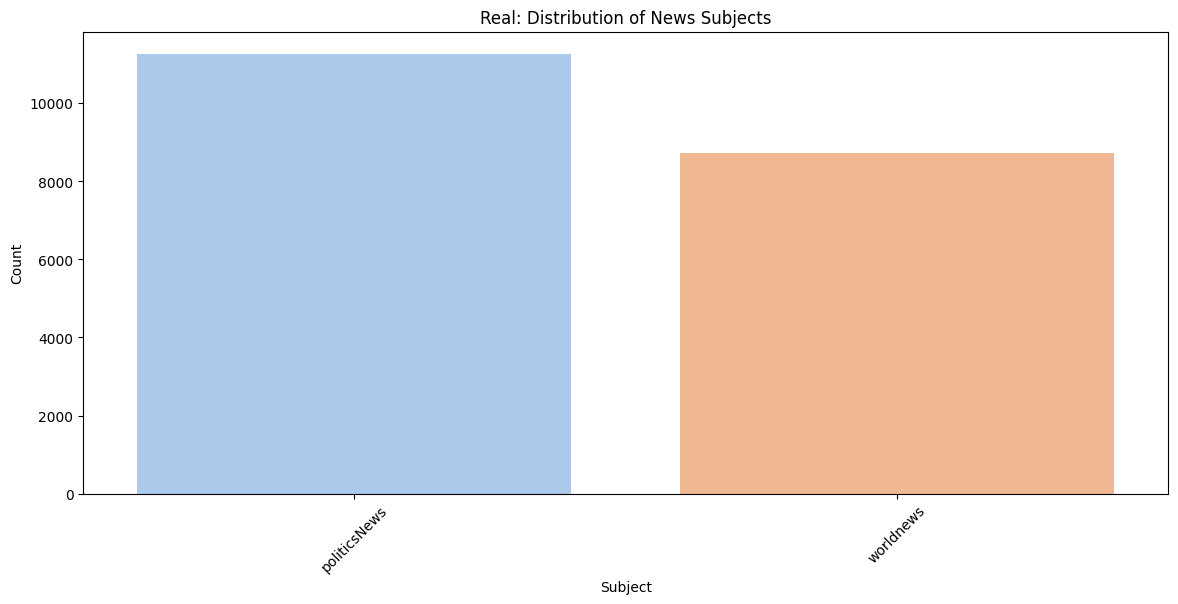

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Calculate counts for each subject
r_subject_counts = data[data['label'] == 1]['subject'].value_counts().reset_index()
r_subject_counts.columns = ['subject', 'count']

# Create the bar plot
plt.figure(figsize=(14, 6))
sns.barplot(data=r_subject_counts, x='subject', y='count', hue='subject', palette='pastel', legend=False)
plt.title('Real: Distribution of News Subjects')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

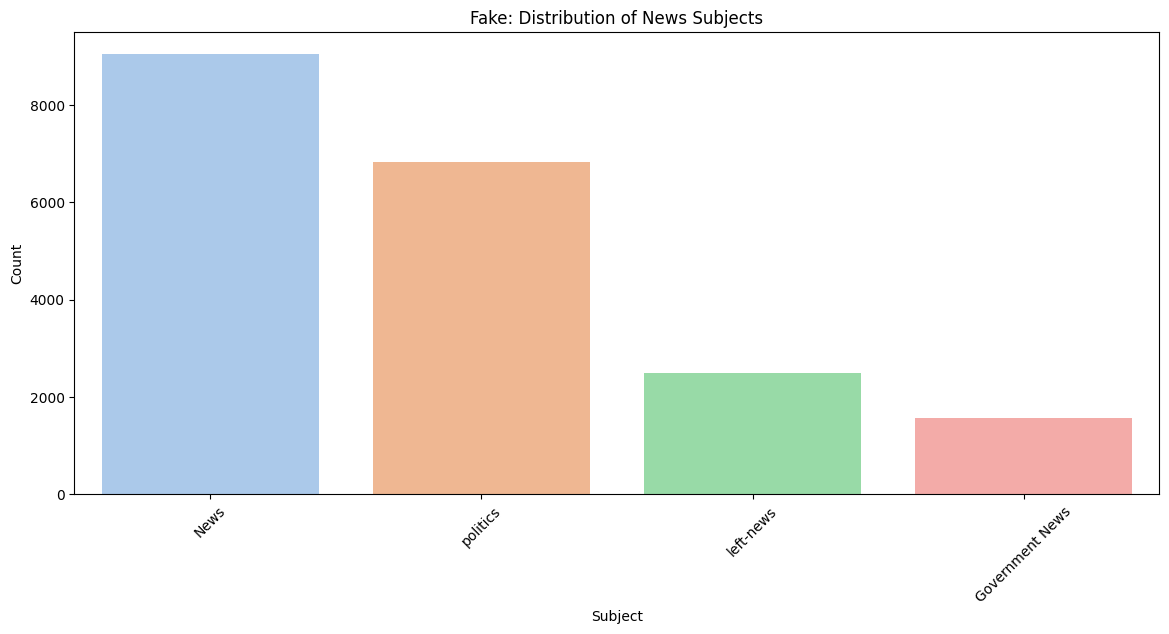

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Calculate counts for each subject
f_subject_counts = data[data['label'] == 0]['subject'].value_counts().reset_index()
f_subject_counts.columns = ['subject', 'count']

# Create the bar plot
plt.figure(figsize=(14, 6))
sns.barplot(data=f_subject_counts, x='subject', y='count', hue='subject', palette='pastel', legend=False)
plt.title('Fake: Distribution of News Subjects')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Data Cleanup

In [ ]:
# Data Cleanup
import re

def clean_links(text):
  # clean https and links from text
  text = re.sub(r'http\S+', '', text)
  text = re.sub(r'www\S+', '', text)
  return text

def clean_punctuations(text):
  text = re.sub(r'[^\w\s]', '', text)
  return text

def data_cleanup(text):
  text = text.lower()
  text = clean_links(text)
  text = clean_punctuations(text)
  return text


# Bag Of Words

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from scipy.sparse import hstack
import numpy as np
from sklearn.model_selection import train_test_split


y = data['label']
data['text'] = data['text'].apply(data_cleanup)
data['title'] = data['title'].apply(data_cleanup)

# train test split
X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=0.2, random_state=42, stratify=y)

# Transform Train

cnt_vec_text = CountVectorizer(stop_words="english")
cnt_vec_title = CountVectorizer(stop_words="english")


# 1. Process Text using CountVectorizer
bow_text_X_train = cnt_vec_text.fit_transform(X_train["text"])

# 2. Process Title using CountVectorizer
bow_title_X_train = cnt_vec_title.fit_transform(X_train["title"])

# Transform Test
bow_text_X_test = cnt_vec_text.transform(X_test["text"])
bow_title_X_test = cnt_vec_title.transform(X_test["title"])


# 3. Combine all features
bow_X_C_train = hstack([bow_text_X_train, bow_title_X_train])
bow_X_C_test = hstack([bow_text_X_test, bow_title_X_test])

print(f"Combined Training Feature Matrix Shape: {bow_X_C_train.shape}")
print(f"Combined Testing Feature Matrix Shape: {bow_X_C_test.shape}")

Combined Training Feature Matrix Shape: (31953, 205521)
Combined Testing Feature Matrix Shape: (7989, 205521)


# TF-IDF

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from scipy.sparse import hstack
import numpy as np
from sklearn.model_selection import train_test_split

y = data['label']
data['text'] = data['text'].apply(data_cleanup)
data['title'] = data['title'].apply(data_cleanup)

# train test split
X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=0.2, random_state=42, stratify=y)

# Transform Train
tfidf_vec_text = TfidfVectorizer()
tfidf_vec_title = TfidfVectorizer()

text_X_train = tfidf_vec_text.fit_transform(X_train["text"])
title_X_train = tfidf_vec_title.fit_transform(X_train["title"])

# Transform Test
text_X_test = tfidf_vec_text.transform(X_test["text"])
title_X_test = tfidf_vec_title.transform(X_test["title"])

# 3. Combine all features
X_C_train = hstack([text_X_train, title_X_train])
X_C_test = hstack([text_X_test, title_X_test])

print(f"Combined Training Feature Matrix Shape: {X_C_train.shape}")
print(f"Combined Testing Feature Matrix Shape: {X_C_test.shape}")


Combined Training Feature Matrix Shape: (31953, 206105)
Combined Testing Feature Matrix Shape: (7989, 206105)


# Plot Metrics

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error, r2_score
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_metrics(title, y_test, y_pred):
  # Calculate Classification Metrics
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  # Calculate Error Metrics
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  # r2 = r2_score(y_test, y_pred)

  # Prepare data for plotting
  metrics_names = ['Precision', 'Recall', 'F1-Score', 'MSE', 'RMSE']
  metrics_values = [precision, recall, f1, mse, rmse]

  # display(classification_report(y_test, y_pred, target_names=['Fake News', 'Real News']))

  # Plotting using pastel palette
  plt.figure(figsize=(5, 3))
  sns.barplot(x=metrics_names, y=metrics_values, hue=metrics_names, palette='pastel', legend=False, edgecolor='black', alpha=0.8)

  # Adding values on top of the bars
  for i, val in enumerate(metrics_values):
      plt.text(i, val + 0.01, f'{val:.4f}', ha='center', fontweight='bold')

  plt.title(title)
  plt.ylabel('Score / Error Value')
  plt.ylim(0, 1.1)
  plt.grid(axis='y', linestyle='--', alpha=0.3)
  plt.show()



# Classifiers

## Naive Bayes Classification

In [ ]:
# Grid Search
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import BernoulliNB

param_grid = {
    'alpha': [0.01, 0.001, 0.002, 0.004]
}

print(data['label'].value_counts())
print(y_train.value_counts())

grid_search_nb = GridSearchCV(BernoulliNB(), param_grid, cv=5, scoring='accuracy')

print("Performing grid search...")
grid_search_nb.fit(X_C_train, y_train)
print("Grid search completed")
print("Best parameters: ", grid_search_nb.best_params_)
print("Best score: ", grid_search_nb.best_score_)

nb_best_model = grid_search_nb.best_estimator_

label
1    19999
0    19943
Name: count, dtype: int64
label
1    15999
0    15954
Name: count, dtype: int64
Performing grid search...
Grid search completed
Best parameters:  {'alpha': 0.001}
Best score:  0.9844771537831101


### Result of Naive Bayes

Naive Bayes Summary:
Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3989
           1       0.99      0.98      0.99      4000

    accuracy                           0.99      7989
   macro avg       0.99      0.99      0.99      7989
weighted avg       0.99      0.99      0.99      7989


Confusion Matrix



array([[3947,   42],
       [  71, 3929]])

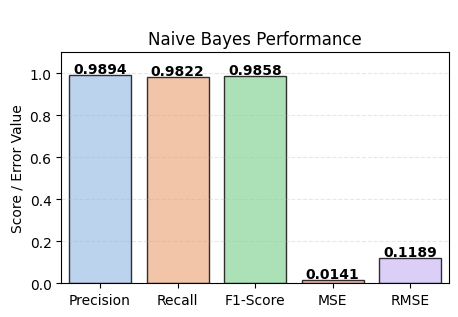

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, r2_score, confusion_matrix

# 4. Predict and Evaluate
y_pred_nb = nb_best_model.predict(X_C_test)

#5. print summary
print("Naive Bayes Summary:")
print(f"Classification Report\n{classification_report(y_test, y_pred_nb)}\n")
# print(f"R2 Score: {r2_score(y_test, y_pred_nb)}\n")
print(f"Confusion Matrix\n")
display(confusion_matrix(y_test, y_pred_nb))

plot_metrics("\nNaive Bayes Performance", y_test, y_pred_nb)

## Linear Regression Model

In [ ]:
# Grid Search
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'fit_intercept': [True],
    'max_iter': [2000, 3000]
}

lr_grid_search = GridSearchCV(LogisticRegression(), param_grid_lr, cv=5, scoring='accuracy')

print("Performing grid search...")
lr_grid_search.fit(X_C_train, y_train)
print("Grid search completed")
print("Best parameters: ", lr_grid_search.best_params_)
print("Best score: ", lr_grid_search.best_score_)

lr_best_model = lr_grid_search.best_estimator_

Performing grid search...
Grid search completed
Best parameters:  {'fit_intercept': True, 'max_iter': 3000, 'penalty': 'l1', 'solver': 'liblinear'}
Best score:  0.9954620996026053


### Result of Linear Regression

Logistic Regression Performance Summary:
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3989
           1       1.00      1.00      1.00      4000

    accuracy                           1.00      7989
   macro avg       1.00      1.00      1.00      7989
weighted avg       1.00      1.00      1.00      7989


R2 Score: 0.9859806969165205

Confusion Matrix



array([[3970,   19],
       [   9, 3991]])

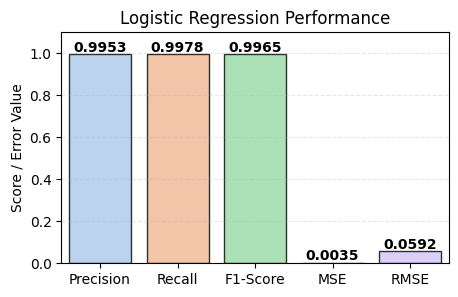

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, r2_score, confusion_matrix

# 4. Predict and Evaluate
y_pred_lr = lr_best_model.predict(X_C_test)

#5. print summary
print("Logistic Regression Performance Summary:")
print(f"Classification Report\n{classification_report(y_test, y_pred_lr)}\n")
print(f"R2 Score: {r2_score(y_test, y_pred_lr)}\n")
print(f"Confusion Matrix\n")
display(confusion_matrix(y_test, y_pred_lr))

plot_metrics("Logistic Regression Performance", y_test, y_pred_lr)

## Support Vector Machine Model

### With Bag of Words

In [ ]:
# Grid Search with BOW
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid_svm = {
    'penalty': ['l1'],
    'dual': [False],
    'max_iter': [2000, 3000, 4000]
}

grid_search_svm_bow = GridSearchCV(LinearSVC(), param_grid_svm, cv=5, scoring='accuracy')

print("Performing grid search...")
grid_search_svm_bow.fit(bow_X_C_train, y_train)
print("Grid search completed")
print("Best parameters: ", grid_search_svm_bow.best_params_)
print("Best score: ", grid_search_svm_bow.best_score_)

svm_bow_best_model = grid_search_svm_bow.best_estimator_

Performing grid search...
Grid search completed
Best parameters:  {'dual': False, 'max_iter': 2000, 'penalty': 'l1'}
Best score:  0.9966826246514013


#### Result of Linear Support Vector Machines with Bag of Words

Logistic Regression Performance Summary:
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3989
           1       1.00      1.00      1.00      4000

    accuracy                           1.00      7989
   macro avg       1.00      1.00      1.00      7989
weighted avg       1.00      1.00      1.00      7989


R2 Score: 0.9864813863123589

Confusion Matrix



array([[3979,   10],
       [  17, 3983]])

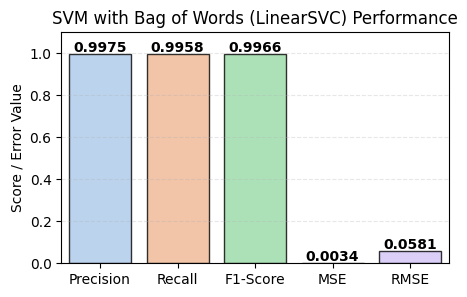

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, r2_score, confusion_matrix

# 4. Predict and Evaluate
y_pred_svm_bow = svm_bow_best_model.predict(bow_X_C_test)

#5. print summary
print("Logistic Regression Performance Summary:")
print(f"Classification Report\n{classification_report(y_test, y_pred_svm_bow)}\n")
print(f"R2 Score: {r2_score(y_test, y_pred_svm_bow)}\n")
print(f"Confusion Matrix\n")
display(confusion_matrix(y_test, y_pred_svm_bow))

plot_metrics("SVM with Bag of Words (LinearSVC) Performance", y_test, y_pred_svm_bow)

### With TF-IDF

In [ ]:
# Grid Search
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid_svm = {
    'penalty': ['l1'],
    'dual': [False],
    'max_iter': [2000, 3000, 4000]
}

grid_search_svm = GridSearchCV(LinearSVC(), param_grid_svm, cv=5, scoring='accuracy')

print("Performing grid search...")
grid_search_svm.fit(X_C_train, y_train)
print("Grid search completed")
print("Best parameters: ", grid_search_svm.best_params_)
print("Best score: ", grid_search_svm.best_score_)

svm_best_model = grid_search_svm.best_estimator_

Performing grid search...
Grid search completed
Best parameters:  {'dual': False, 'max_iter': 2000, 'penalty': 'l1'}
Best score:  0.9972146668498272


#### Result of Linear Support Vector Machines with TF-IDF

Logistic Regression Performance Summary:
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3989
           1       1.00      1.00      1.00      4000

    accuracy                           1.00      7989
   macro avg       1.00      1.00      1.00      7989
weighted avg       1.00      1.00      1.00      7989


R2 Score: 0.9924896590624217

Confusion Matrix



array([[3977,   12],
       [   3, 3997]])

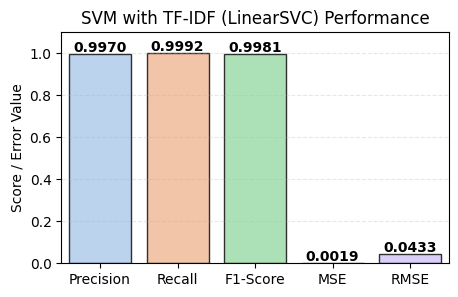

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, r2_score, confusion_matrix

# 4. Predict and Evaluate
y_pred_svm = svm_best_model.predict(X_C_test)

#5. print summary
print("Logistic Regression Performance Summary:")
print(f"Classification Report\n{classification_report(y_test, y_pred_svm)}\n")
print(f"R2 Score: {r2_score(y_test, y_pred_svm)}\n")
print(f"Confusion Matrix\n")
display(confusion_matrix(y_test, y_pred_svm))

plot_metrics("SVM with TF-IDF (LinearSVC) Performance", y_test, y_pred_svm)

# Aggregate Report

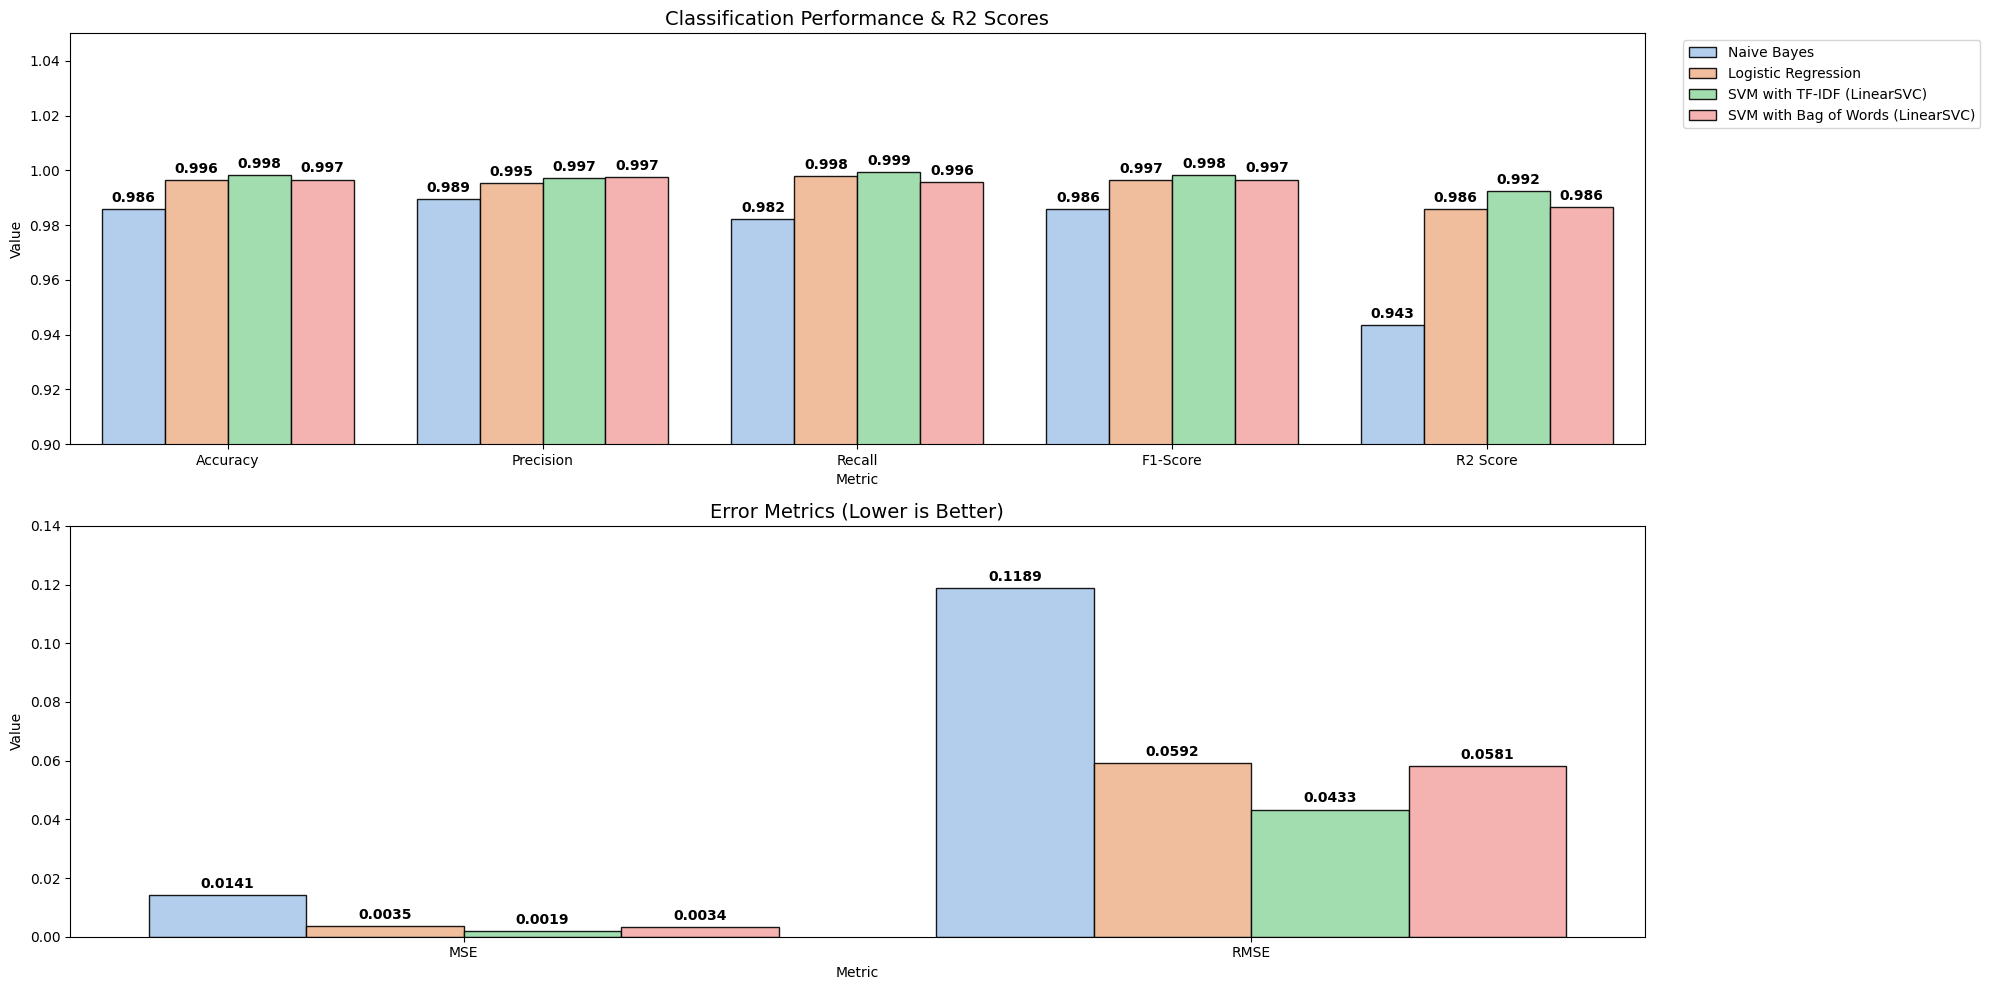

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, mean_squared_error, r2_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define the models and their predictions
model_results = [
    ('Naive Bayes', y_pred_nb),
    ('Logistic Regression', y_pred_lr),
    ('SVM with TF-IDF (LinearSVC)', y_pred_svm),
    ('SVM with Bag of Words (LinearSVC)', y_pred_svm_bow)
]

# Gather metrics for each model
metrics_data = []
for name, pred in model_results:
    mse_val = mean_squared_error(y_test, pred)
    metrics_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'MSE': mse_val,
        'RMSE': np.sqrt(mse_val),
        'R2 Score': r2_score(y_test, pred)
    })

# Convert to DataFrame
df_all = pd.DataFrame(metrics_data)

# Move R2 Score to the error metrics plot or keep it in scores with a wider scale
# Let's keep R2 Score in ax1 but expand the Y-axis limit
score_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'R2 Score']
error_metrics = ['MSE', 'RMSE']

df_scores = df_all.melt(id_vars='Model', value_vars=score_metrics, var_name='Metric', value_name='Value')
df_errors = df_all.melt(id_vars='Model', value_vars=error_metrics, var_name='Metric', value_name='Value')

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))

# Plot Scores - Adjusted Y-limit to catch lower R2 scores
sns.barplot(data=df_scores, x='Metric', y='Value', hue='Model', palette='pastel', ax=ax1, edgecolor='black', alpha=0.9)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f', padding=3, fontweight='bold')
ax1.set_title('Classification Performance & R2 Scores', fontsize=14)
ax1.set_ylim(0.9, 1.05) # Lowered limit to make R2 visible for all models
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Plot Errors
sns.barplot(data=df_errors, x='Metric', y='Value', hue='Model', palette='pastel', ax=ax2, edgecolor='black', alpha=0.9)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.4f', padding=3, fontweight='bold')
ax2.set_title('Error Metrics (Lower is Better)', fontsize=14)
ax2.set_ylim(0.0, 0.14) # Lowered limit to make R2 visible for all models
ax2.legend().set_visible(False)

plt.tight_layout()
plt.show()

# Test with Real Data


In [ ]:
raw_real_data = pd.read_csv(real_data_url)

real_data = raw_real_data.copy()

# cleanup
real_data['text'] = real_data['text'].apply(data_cleanup)
real_data['title'] = real_data['title'].apply(data_cleanup)

# embedding - MUST use the original transformers fitted on training data
# 1. Process Real Text
X_real_text = tfidf_vec_text.transform(real_data["text"])

# 2. Process Real Title
X_real_title = tfidf_vec_title.transform(real_data["title"])

# 3. Combine features (Matching the training format [X_text, X_title])
X_C_real = hstack([X_real_text, X_real_title])

# Predict using the trained models
result_nb_real = nb_best_model.predict(X_C_real)
result_lr_real = lr_best_model.predict(X_C_real)
result_svm_real = svm_best_model.predict(X_C_real)

# Display some results
# real_data['NB_Prediction'] = result_nb_real
# real_data['LR_Prediction'] = result_lr_real
real_data['SVM_Prediction'] = result_svm_real

result = raw_real_data.copy()
result['label'] = result_svm_real


display(result)

,label,title,text,subject,date
0,1,UK's May 'receiving regular updates' on London...,LONDON (Reuters) - British Prime Minister Ther...,worldnews,"September 15, 2017"
1,1,UK transport police leading investigation of L...,LONDON (Reuters) - British counter-terrorism p...,worldnews,"September 15, 2017"
2,1,Pacific nations crack down on North Korean shi...,WELLINGTON (Reuters) - South Pacific island na...,worldnews,"September 15, 2017"
3,1,Three suspected al Qaeda militants killed in Y...,"ADEN, Yemen (Reuters) - Three suspected al Qae...",worldnews,"September 15, 2017"
4,1,Chinese academics prod Beijing to consider Nor...,BEIJING (Reuters) - Chinese academics are publ...,worldnews,"September 15, 2017"
...,...,...,...,...,...
4951,0,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
4952,0,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
4953,0,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
4954,0,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [ ]:
# Export the results to a CSV file
output_filename = 'real_data_predictions.csv'
result.to_csv(output_filename, index=False)

print(f"Results successfully exported to {output_filename}")

Results successfully exported to real_data_predictions.csv
